In [1]:
import pandas as pd
from datetime import timezone, datetime, timedelta

import sys
import os

from time import sleep

p = os.path.abspath("../src")
if p not in sys.path:
    sys.path.insert(0, p)

from settings import AUTH_TOKEN
from tv.data_loader import TVDataLoader

from functools import reduce

pd.options.display.width = 300
pd.options.display.max_rows = 1500
pd.options.display.max_columns = None
pd.options.display.max_colwidth = None
pd.options.display.expand_frame_repr = False


timeframe = "3H"
session = "regular"


stocks = ["URA", "COPX", "REMX",]

futures = [
    # "ES", "NQ", "YM", "6A", "6B", "6C", "6E", "6J", "6N",
    # "DX", "6S", "CL", "NG", "RB", "ZC", "KE", "ZO", "ZR", "ZM",
    # "ZL", "ZS", "ZW", "ZB",

    # 1 day
    # "UX", "EH", "TF",

    # "ES", "YM", "6A", "6B", "6C", "6E", "6J", "6N", "CL", "NG", "ZO", "ZR", "ZM", "ZL", "ZS", "ZW", "ZB",

    "ES", "YM", "6A", "6B", "6C", "6E", "6J", "6N", "CL", "NG", "ZO", "ZR", "ZM", "ZL", "ZS", "ZW", "ZB",
]



In [2]:


dfs = []

# for f in stocks:
#     df = TVDataLoader(AUTH_TOKEN, f, timeframe, session).run()
#     df = df[["c"]].set_axis([f], axis=1)
#     dfs.append(df)
#     sleep(1)

for f in futures:
    df = TVDataLoader(AUTH_TOKEN, f"{f}1!", timeframe, session).run()
    df = df[["c"]].set_axis([f], axis=1)
    dfs.append(df)
    sleep(1)

# df = reduce(lambda *x: pd.merge(*x, on='dt'), dfs)




Symbol: CME_MINI_DL:ES1!
Description: E-MINI S&P 500 FUTURES (CONTINUOUS: CURRENT CONTRACT IN FRONT)
Type: futures
Currency: USD
Exchange: CME_MINI
Timezone: America/Chicago
Sessions: regular, us_regular
Columns: ohlcv


2022-12-16 02:14:09


2018-01-01 23:00:00


2013-01-02 11:00:00


Symbol: CBOT_MINI_DL:YM1!
Description: E-MINI DOW ($5) FUTURES (CONTINUOUS: CURRENT CONTRACT IN FRONT)
Type: futures
Currency: USD
Exchange: CBOT_MINI
Timezone: America/Chicago
Sessions: regular, us_regular
Columns: ohlcv


2022-12-16 02:14:13


2018-01-01 23:00:00


2013-01-02 11:00:00


Symbol: CME_DL:6A1!
Description: AUSTRALIAN DOLLAR FUTURES (CONTINUOUS: CURRENT CONTRACT IN FRONT)
Type: futures
Currency: USD
Exchange: CME
Timezone: America/Chicago
Sessions: regular, us_regular
Columns: ohlcv


2022-12-16 02:14:17


2018-01-01 23:00:00


2013-01-02 11:00:00


Symbol: CME_DL:6B1!
Description: BRITISH POUND FUTURES (CONTINUOUS: CURRENT CONTRACT IN FRONT)
Type: futures
Currency: USD
Exchange: CME
Timez

TypeError: 'NoneType' object is not subscriptable

In [ ]:


# df_1 = TVDataLoader(AUTH_TOKEN, "ZC1!", timeframe, session).run()
# # df_2 = TVDataLoader(AUTH_TOKEN, "HG1!", timeframe, session).run()

# df_p = df_1[df_1.index >= "2022-08-12"].resample('D').fillna("ffill")[["c"]]
# df_p["c+1d"] = df_p["c"].shift(1)
# df_p["c+2d"] = df_p["c"].shift(2)
# df_p["c+3d"] = df_p["c"].shift(3)
# df_p["c+4d"] = df_p["c"].shift(4)

# # df_1 = df_1[["c"]].set_axis(['COPX'], axis=1)
# # df_2 = df_2[["c"]].set_axis(['HG1!'], axis=1)


# df = pd.read_csv("../../data/BSGI.tsv", sep="\t", thousands=',')

# df = df[df["Commodity"] == "Corn"]

# df["departure"] = pd.to_datetime(df["Departure date"])
# df["inspection"] = pd.to_datetime(df["Inspection cleared"])

# df_inspection = df[["inspection", "Metric tons"]].groupby("inspection").sum().reset_index()
# df_inspection.columns = ["dt", "inspection"]

# df_departure = df[["departure", "Metric tons"]].groupby("departure").sum().reset_index()
# df_departure.columns = ["dt", "departure"]

# df = pd.merge(df_departure, df_inspection, on="dt", how="outer")

# df = df.set_index("dt").resample('D').asfreq()
# df = df.fillna(0).astype(int)

# df = pd.merge(df, df_p, on="dt", how="outer")


# df = df.sort_index()

# print(df.corr().round(2))

# df




In [44]:
# dfs[5]
# dfs[0]

df = reduce(lambda *x: pd.merge(*x, on='dt', how="outer"), dfs)

df = df.round(4).resample("1H").last()

df = df[df.index > "2021-01-01"]

df

f_name = "../../data/futures-21-22.csv"
df.to_csv(f_name)


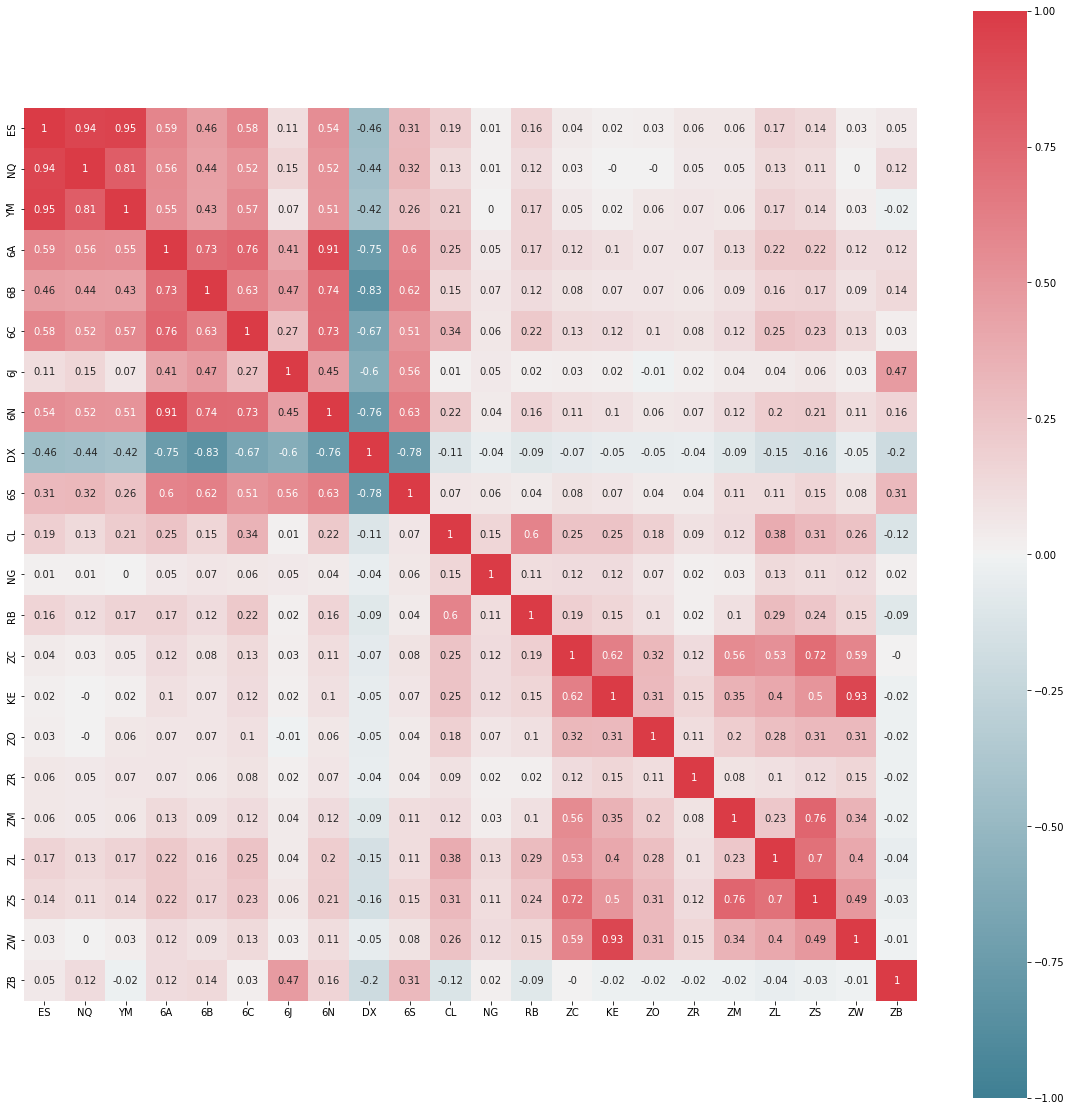

In [9]:

# dfs = [df_1, df_2]

# df = reduce(lambda *x: pd.merge(*x, on='dt'), dfs)

# for i, d in enumerate(dfs):
#     # d['date'] = pd.to_datetime(d.index).date
#     print(d.tail())

# print(df.head())
# print()
# print(df.tail())

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.pct_change(periods=1).corr(numeric_only=True).round(2)

# sns.heatmap(corr, xticklabels=corr.columns.values, yticklabels=corr.columns.values)

# f = plt.figure(figsize=(22, 22))
# plt.matshow(, fignum=f.number)
# plt.show()

# idx = "DX"
# corr_sorted = corr.sort_values(idx, ascending=False).T.sort_values(idx, ascending=False).abs()


# Find index of feature columns with correlation greater than 0.95
# upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(np.bool))
# to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]
# print(to_drop)


# Drop features 
# df.drop(df[to_drop], axis=1)

f, ax = plt.subplots(figsize=(20, 20))

hm = sns.heatmap(
    # upper,
    corr,
    # corr_sorted,
    cmap=sns.diverging_palette(220, 10, as_cmap=True),
    vmin=-1.0, vmax=1.0,
    square=True,
    annot=True,
    ax=ax,
)



# import plotly.express as px
# fig = px.imshow(corr)
# fig.show()

# URA: copx, remx, es, nq, 6a, 6c, 6n
# COPX: fcx, ura, remx, es, 6a, 6n, cl
# REMX: copx, es, nq, 6a, 6n


In [135]:
df.columns

,URA,COPX,REMX,ES,NQ,YM,TF,6A,6B,6C,6E,6J,6N,DX,6S,CL,NG,RB,ZC,KE,ZO,ZR,ZM,ZL,ZS,ZW,ZB
dt,,,,,,,,,,,,,,,,,,,,,,,,,,,
